Sample Data:
    user_id                   timestamp      group landing_page  converted
0   851104  2017-01-21 22:11:48.556739    control     old_page          0
1   804228  2017-01-12 08:01:45.159739    control     old_page          0
2   661590  2017-01-11 16:55:06.154213  treatment     new_page          0
3   853541  2017-01-08 18:28:03.143765  treatment     new_page          0
4   864975  2017-01-21 01:52:26.210827    control     old_page          1
Z-score: -1.24, p-value: 0.8919


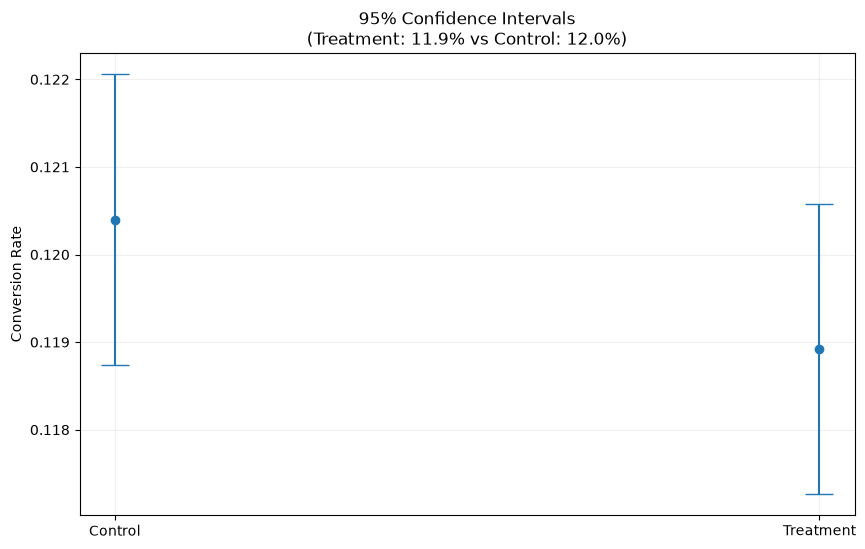

Chi-square p-value for landing_page: 0.17299
Required sample per group (based on effect size 0.2): 393


In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import TTestIndPower

# Assuming your dataset is loaded into a DataFrame named 'ab_data'
ab_data = pd.read_csv('ab_data.csv')

print("Sample Data:\n", ab_data.head())

# ---------------------------------------------------------
# 1. Two-Proportion Z-Test
# ---------------------------------------------------------
# Formulate Hypotheses:
# H0: New design conversion rate <= Old design 
# H1: New design conversion rate > Old design 

# Extract conversion counts
conv_old = ab_data[ab_data['group'] == 'control']['converted'].sum()
conv_new = ab_data[ab_data['group'] == 'treatment']['converted'].sum()

# Extract group sizes
n_old = ab_data[ab_data['group'] == 'control'].shape[0]
n_new = ab_data[ab_data['group'] == 'treatment'].shape[0]

# Perform Z-test (One-tailed test, alternative='larger')
z_score, p_value = proportions_ztest(
    count=[conv_new, conv_old],
    nobs=[n_new, n_old],
    alternative='larger'
)

print(f"Z-score: {z_score:.2f}, p-value: {p_value:.4f}")

# ---------------------------------------------------------
# 2. Confidence Interval Visualization
# ---------------------------------------------------------
# Calculate 95% CIs
ci_old = proportion_confint(conv_old, n_old, alpha=0.05)
ci_new = proportion_confint(conv_new, n_new, alpha=0.05)

# Calculate rates for plotting
rate_old = conv_old / n_old
rate_new = conv_new / n_new

# Plot results
plt.figure(figsize=(10, 6))
plt.errorbar(
    x=[0, 1], 
    y=[rate_old, rate_new],
    yerr=[[rate_old - ci_old[0], rate_new - ci_new[0]], 
          [ci_old[1] - rate_old, ci_new[1] - rate_new]],
    fmt='o', 
    capsize=10
)
plt.xticks([0, 1], ['Control', 'Treatment'])
plt.ylabel('Conversion Rate')
plt.title(f'95% Confidence Intervals\n(Treatment: {rate_new*100:.1f}% vs Control: {rate_old*100:.1f}%)')
plt.grid(alpha=0.2)
plt.show()

# ---------------------------------------------------------
# 3. Advanced Testing Scenarios: Chi-Square Test
# ---------------------------------------------------------
# Test if landing_page type affects conversion (Categorical Relationship)
contingency_table = pd.crosstab(ab_data['landing_page'], ab_data['converted'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-square p-value for landing_page: {p:.5f}")

# ---------------------------------------------------------
# 4. Experimental Design Principles: Sample Size Calculation
# ---------------------------------------------------------
effect_size = 0.2  # Minimum detectable effect
power = 0.8        # Standard power level
alpha = 0.05

analysis = TTestIndPower()
sample_size = analysis.solve_power(effect_size=effect_size, power=power, alpha=alpha)

print(f"Required sample per group (based on effect size 0.2): {int(sample_size)}")